# Application Test Dataset – Clustering Objectives

## Objective
The objective of the application test dataset is to apply trained clustering techniques to new/unseen records and determine which existing cluster each record is most similar to.

## Application Objectives

1. Load new application/test data.
2. Perform the same preprocessing used on the training dataset.
3. Handle missing values and invalid records.
4. Encode categorical variables where required.
5. Apply the same feature scaling used during model development.
6. Select the same clustering features used during training.
7. Assign new records to appropriate clusters where the clustering algorithm supports prediction.
8. Analyze the characteristics of each assigned cluster.
9. Compare new records with existing customer/product/sales segments.
10. Generate business recommendations based on cluster membership.

---

# Machine Learning Objective

Develop and compare multiple clustering algorithms:

- K-Means Clustering
- Hierarchical / Agglomerative Clustering
- DBSCAN
- Mean Shift Clustering

Evaluate clustering quality using:

- Elbow Method
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Dendrogram
- Cluster Visualization


# Business Objective – Home Credit Application Dataset

## Business Objective

Home Credit provides loans to customers who may have limited or no traditional credit history. The main business objective is to analyze loan applicant information and identify meaningful groups of applicants with similar financial, demographic, employment, and credit-related characteristics.

Using clustering techniques, the goal is to discover hidden customer segments without using a predefined target variable.

## Clustering Objectives

1. **Applicant Segmentation**
   - Group loan applicants based on similar financial and demographic characteristics.
   - Identify distinct types of credit applicants.

2. **Income-Based Segmentation**
   - Group applicants based on total income, loan amount, annuity amount, and other financial attributes.
   - Understand differences between low-, medium-, and high-income applicant groups.

3. **Credit Profile Segmentation**
   - Identify applicants with similar credit requirements.
   - Analyze relationships between requested credit amount, income, annuity, and goods price.

4. **Employment Profile Analysis**
   - Segment applicants based on employment-related characteristics.
   - Understand how employment duration, occupation, and income source differ across clusters.

5. **Demographic Segmentation**
   - Identify applicant groups based on age, family size, education, housing type, and other demographic characteristics.

6. **Financial Burden Analysis**
   - Identify groups with different levels of financial burden.
   - Analyze indicators such as:
     - Credit-to-Income Ratio
     - Annuity-to-Income Ratio
     - Credit-to-Goods-Price Ratio

7. **Potential Risk-Pattern Discovery**
   - Discover applicant groups whose characteristics may warrant different levels of credit review.
   - Clustering itself should not be treated as a loan-default prediction model because the test dataset does not contain the target/default label.

8. **Outlier Detection**
   - Identify applicants with unusual income, credit, annuity, employment, or demographic characteristics.
   - Detect applicants significantly different from the majority of customers.

9. **Business Decision Support**
   - Support customer segmentation and portfolio analysis.
   - Help design differentiated loan products and customer communication strategies.
   - Provide additional insights that can complement supervised credit-risk models.

## Machine Learning Objective

Apply unsupervised machine learning algorithms such as:

- K-Means Clustering
- Hierarchical / Agglomerative Clustering
- DBSCAN
- Mean Shift Clustering

Evaluate the quality of the generated clusters using:

- Elbow Method
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Cluster Visualization

## Expected Outcome

The expected outcome is to divide Home Credit loan applicants into meaningful customer segments based on similarities in their financial, demographic, employment, and credit characteristics.

These clusters can then be profiled to understand different types of loan applicants and support portfolio analysis, customer segmentation, credit review, and business strategy.

In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install openpyxl xlrd


   ---------------------------------------- 0/3 [xlrd]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   -------------------------- ------------- 2/3 [openpyxl]
   ---------------------------------------- 3/3 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [17]:
insurance_dataset = pd.read_excel("C:/clustering/data/application_test.xlsx")

In [ ]:
insurance_dataset=insurance_dataset[['Row ID','Order ID','Order Date','Ship Mode','Cutomer ID','Customer Name','Segment','Country/Region','City','Postal Code','Region','Product ID','Category','Sub-Category','Product Name','Sales','Quantity','Discount','Profit']]

In [5]:
insurance_dataset

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,2026-12-30,2027-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,2026-12-30,2027-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279


In [ ]:

import pandas as pd                                                                                                                                                                                                                                                                                                                                                                                                      
import numpy as np
from sklearn.cluster import KMeans,AgglomerativeClustering,MeanShift,DBSCAN
insurance_dataset=pd.read_excel('C:\clustering\data\Sample - Superstore.xls')

<>:5: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:5: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\khanr\AppData\Local\Temp\ipykernel_25568\3184384056.py:5: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  insurance_dataset=pd.read_excel('C:\clustering\data\Sample - Superstore.xls')


In [9]:
insurance_dataset=insurance_dataset[['Row ID','Order ID','Order Date','Ship Mode','Customer ID','Customer Name','Segment','Country/Region','City','Postal Code','Region','Product ID','Category','Sub-Category','Product Name','Sales','Quantity','Discount','Profit']]

In [10]:
insurance_dataset.shape

(10194, 19)

In [11]:
insurance_dataset.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [12]:
def fill_null_values(df):
    for column in df.columns:
        if df[column].isna().sum() > 0:
            if df[column].dtype in ['int64', 'float64']:
                df[column] = df[column].fillna(df[column].median())
    
    return df

insurance_dataset = fill_null_values(insurance_dataset)

insurance_dataset.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [13]:
insurance_dataset

,Row ID,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2026-143259,2026-12-30,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,2026-12-30,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,2026-12-30,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,2026-12-30,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279


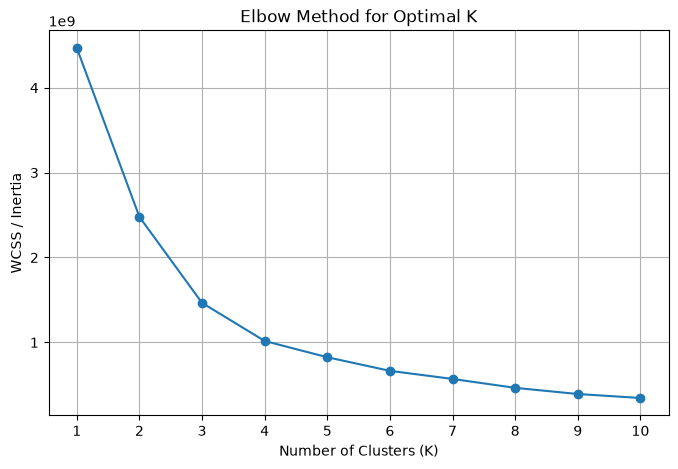

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select numerical features for clustering
X = insurance_dataset[
    [
      
      'Sales',
      'Quantity',
      'Discount',
      'Profit'  
    ]
]

# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid()

plt.show()

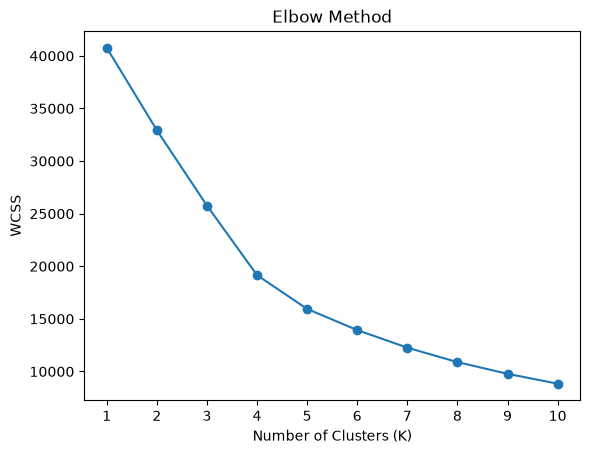

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features
X = insurance_dataset[
    [
        'Sales',
        'Quantity',
        'Discount',
        'Profit'  
    ]
]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS
wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    wcss.append(model.inertia_)

# Elbow Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

In [19]:
from sklearn.cluster import KMeans

# Build K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train and predict clusters
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
insurance_dataset['KMeans_Cluster'] = kmeans_labels

# Check number of records in each cluster
print(insurance_dataset['KMeans_Cluster'].value_counts().sort_index())

KMeans_Cluster
0      77
1    8963
2    1154
Name: count, dtype: int64


In [20]:
X_scaled[0:100]

array([[-3.41645274e-01, -8.04161327e-01,  2.16329470e-01,
        -9.94701994e-02],
       [-3.62468779e-01, -8.04161327e-01,  3.12558294e+00,
        -1.46955782e-01],
       [-3.49169355e-01, -3.55370099e-01,  2.16329470e-01,
        -1.04974521e-01],
       [ 7.18048692e-02, -3.55370099e-01,  2.16329470e-01,
        -4.02007850e-01],
       [-3.36663636e-01, -3.55370099e-01,  2.16329470e-01,
        -1.02340448e-01],
       [ 3.78397052e+00,  2.33737727e+00, -7.53421687e-01,
         3.08764431e+00],
       [-3.59339123e-01, -8.04161327e-01, -7.53421687e-01,
        -1.16985945e-01],
       [-3.47562583e-01, -3.55370099e-01, -7.53421687e-01,
        -1.00809821e-01],
       [ 6.15855235e-01, -8.04161327e-01, -7.53421687e-01,
         1.05749046e+00],
       [-3.17976041e-01,  9.34211287e-02, -7.53421687e-01,
        -1.22012322e-01],
       [-3.57629105e-01, -1.25295255e+00, -7.53421687e-01,
        -1.10409151e-01],
       [-3.36818506e-01, -3.55370099e-01, -7.53421687e-01,
      

In [21]:
from sklearn.cluster import AgglomerativeClustering


# Build Agglomerative model
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

# Train and predict clusters
agg_labels = agg_model.fit_predict(X_scaled[0:100])

In [23]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
agg_score = silhouette_score(X_scaled[0:100], agg_labels)

print("K-Means Silhouette Score:", kmeans_score)
print("Agglomerative Silhouette Score:", agg_score)

K-Means Silhouette Score: 0.5179076015713667
Agglomerative Silhouette Score: 0.5085250403662771
